In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/test.csv")
ORIG = pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv")
print(train_data.shape)
print(test_df.shape)
print(ORIG.shape)

(439140, 16)
(188165, 15)
(101371, 16)


In [3]:
ORIG.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [4]:
ORIG["Compound"] = ORIG["Compound"].fillna("UNKNOWN")

In [5]:
train_data = pd.concat([train_data, ORIG], ignore_index=True)

In [6]:
print("Train data:",train_data.columns.tolist())
print("Test data:",test_df.columns.tolist())

Train data: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'Normalized_TyreLife']
Test data: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


In [7]:
print(train_data.isnull().sum())
train_data = train_data.drop(columns=["Normalized_TyreLife"])

id                        101371
Driver                         0
Compound                       0
Race                           0
Year                           0
PitStop                        0
LapNumber                      0
Stint                          0
TyreLife                       0
Position                       0
LapTime (s)                    0
LapTime_Delta                  0
Cumulative_Degradation         0
RaceProgress                   0
Position_Change                0
PitNextLap                     0
Normalized_TyreLife       439140
dtype: int64


In [8]:
train_data.shape

(540511, 16)

In [9]:
train_data['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET', 'UNKNOWN'],
      dtype=object)

In [10]:
train_data['Compound'] = train_data['Compound'].str.upper().str.strip()
test_df['Compound'] = test_df['Compound'].str.upper().str.strip()

In [11]:
compound_map = {
    'SOFT': 0,
    'MEDIUM': 1,
    'HARD': 2,
    'INTERMEDIATE': 3,
    'WET': 4
}

train_data['Compound'] = train_data['Compound'].map(compound_map)
test_df['Compound'] = test_df['Compound'].map(compound_map)

train_data['Compound']

0         2.0
1         2.0
2         2.0
3         1.0
4         2.0
         ... 
540506    2.0
540507    2.0
540508    2.0
540509    2.0
540510    2.0
Name: Compound, Length: 540511, dtype: float64

In [12]:
train_data['Compound'].isnull().sum()

np.int64(66)

In [13]:
def feature_eng(train_data):
    train_data['PrevLapTime'] = (
        train_data.groupby('Driver')['LapTime (s)'].shift(1))
    train_data['PrevPosition'] = (
        train_data.groupby('Driver')['Position'].shift(1))
    train_data['RollingLapTime'] = (
        train_data.groupby('Driver')['LapTime (s)'].rolling(3).mean().reset_index(0, drop=True))
    train_data['TyreLife_x_Compound'] = (
        train_data['TyreLife'] * train_data['Compound']
    )
    return train_data

In [14]:
feature_eng(train_data)
feature_eng(test_df)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PrevLapTime,PrevPosition,RollingLapTime,TyreLife_x_Compound
0,439140,D119,1,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0,NaN,NaN,NaN,21.0
1,439141,VER,1,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0,NaN,NaN,NaN,24.0
2,439142,D270,1,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0,NaN,NaN,NaN,24.0
3,439143,D112,0,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0,NaN,NaN,NaN,0.0
4,439144,AND,2,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0,NaN,NaN,NaN,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,627300,D171,1,Australian Grand Prix,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,0.179487,-2.0,85.946,7.0,87.965667,14.0
188161,627301,RUS,0,Pre-Season Testing,2025,0,60,3,26.0,4,95.727,7.920,-36.485,0.789474,-3.0,95.473,5.0,96.755667,0.0
188162,627302,D112,1,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0,95.852,13.0,86.514667,21.0
188163,627303,D349,1,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0,84.307,14.0,82.404000,15.0


In [15]:
train_data = train_data.fillna(-999)
test_df = test_df.fillna(-999)
train_data

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,PrevLapTime,PrevPosition,RollingLapTime,TyreLife_x_Compound
0,0.0,D109,2.0,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,-999.000,-999.0,-999.000000,78.0
1,1.0,D086,2.0,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,-999.000,-999.0,-999.000000,14.0
2,2.0,ZON,2.0,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,-999.000,-999.0,-999.000000,44.0
3,3.0,SPE,1.0,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,-999.000,-999.0,-999.000000,2.0
4,4.0,D019,2.0,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,-999.000,-999.0,-999.000000,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540506,-999.0,ZHO,2.0,United States Grand Prix,2022,0,52,3,29.0,12,103.373,26.850,-90.264,0.722222,2.0,0.0,104.328,12.0,103.510667,58.0
540507,-999.0,ZHO,2.0,United States Grand Prix,2022,0,53,3,30.0,13,105.200,27.061,-88.437,0.736111,1.0,0.0,103.373,12.0,104.300333,60.0
540508,-999.0,ZHO,2.0,United States Grand Prix,2022,0,54,3,31.0,13,104.102,27.149,-89.535,0.750000,0.0,0.0,105.200,13.0,104.225000,62.0
540509,-999.0,ZHO,2.0,United States Grand Prix,2022,0,55,3,32.0,14,103.812,4.428,-89.825,0.763889,-1.0,0.0,104.102,13.0,104.371333,64.0


In [16]:
train_data['Driver'].nunique()

887

In [17]:
train_data['Race'].unique()

array(['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix',
       'Pre-Season Testing', 'Azerbaijan Grand Prix',
       'Saudi Arabian Grand Prix', 'Belgian Grand Prix',
       'United States Grand Prix', 'Italian Grand Prix',
       'Hungarian Grand Prix', 'Japanese Grand Prix',
       'São Paulo Grand Prix', 'Bahrain Grand Prix',
       'Las Vegas Grand Prix', 'Monaco Grand Prix', 'British Grand Prix',
       'Australian Grand Prix', 'Spanish Grand Prix', 'Miami Grand Prix',
       'French Grand Prix', 'Abu Dhabi Grand Prix', 'Chinese Grand Prix',
       'Mexico City Grand Prix', 'Emilia Romagna Grand Prix',
       'Singapore Grand Prix', 'Qatar Grand Prix', 'Pre-Season Test',
       'Pre-Season Track Session'], dtype=object)

In [18]:
# Save groups first
groups = train_data['Race']

In [19]:
from category_encoders import CatBoostEncoder
from sklearn.model_selection import GroupKFold
import numpy as np

# New encoded columns
train_data['Driver_CB'] = np.nan
test_df['Driver_CB'] = 0

train_data['Race_CB'] = np.nan
test_df['Race_CB'] = 0

# Groups
groups = train_data['Race']

# GroupKFold
gkf = GroupKFold(n_splits=5)

for train_idx, val_idx in gkf.split(
    train_data,
    train_data['PitNextLap'],
    groups
):

    X_train = train_data.iloc[train_idx]
    X_val = train_data.iloc[val_idx]

    y_train = X_train['PitNextLap']

    # Encoder
    encoder = CatBoostEncoder(
        cols=['Driver', 'Race']
    )

    # Fit on train fold only
    encoder.fit(
        X_train[['Driver', 'Race']],
        y_train
    )

    # Validation encoding
    val_encoded = encoder.transform(
        X_val[['Driver', 'Race']]
    )

    train_data.loc[val_idx, 'Driver_CB'] = (
        val_encoded['Driver']
    )

    train_data.loc[val_idx, 'Race_CB'] = (
        val_encoded['Race']
    )

    # Test encoding
    test_encoded = encoder.transform(
        test_df[['Driver', 'Race']]
    )

    test_df['Driver_CB'] += (
        test_encoded['Driver'] / gkf.n_splits
    )

    test_df['Race_CB'] += (
        test_encoded['Race'] / gkf.n_splits
    )

In [20]:
train_data.drop(columns=['Driver', 'Race'], inplace=True)
test_df.drop(columns=['Driver', 'Race'], inplace=True)

train_data.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [21]:
train_data['Race_CB']

0         0.219496
1         0.206538
2         0.219496
3         0.205573
4         0.205573
            ...   
540506    0.204869
540507    0.204869
540508    0.204869
540509    0.204869
540510    0.204869
Name: Race_CB, Length: 540511, dtype: float64

In [22]:
train_data.columns

Index(['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'PitNextLap', 'PrevLapTime',
       'PrevPosition', 'RollingLapTime', 'TyreLife_x_Compound', 'Driver_CB',
       'Race_CB'],
      dtype='object')

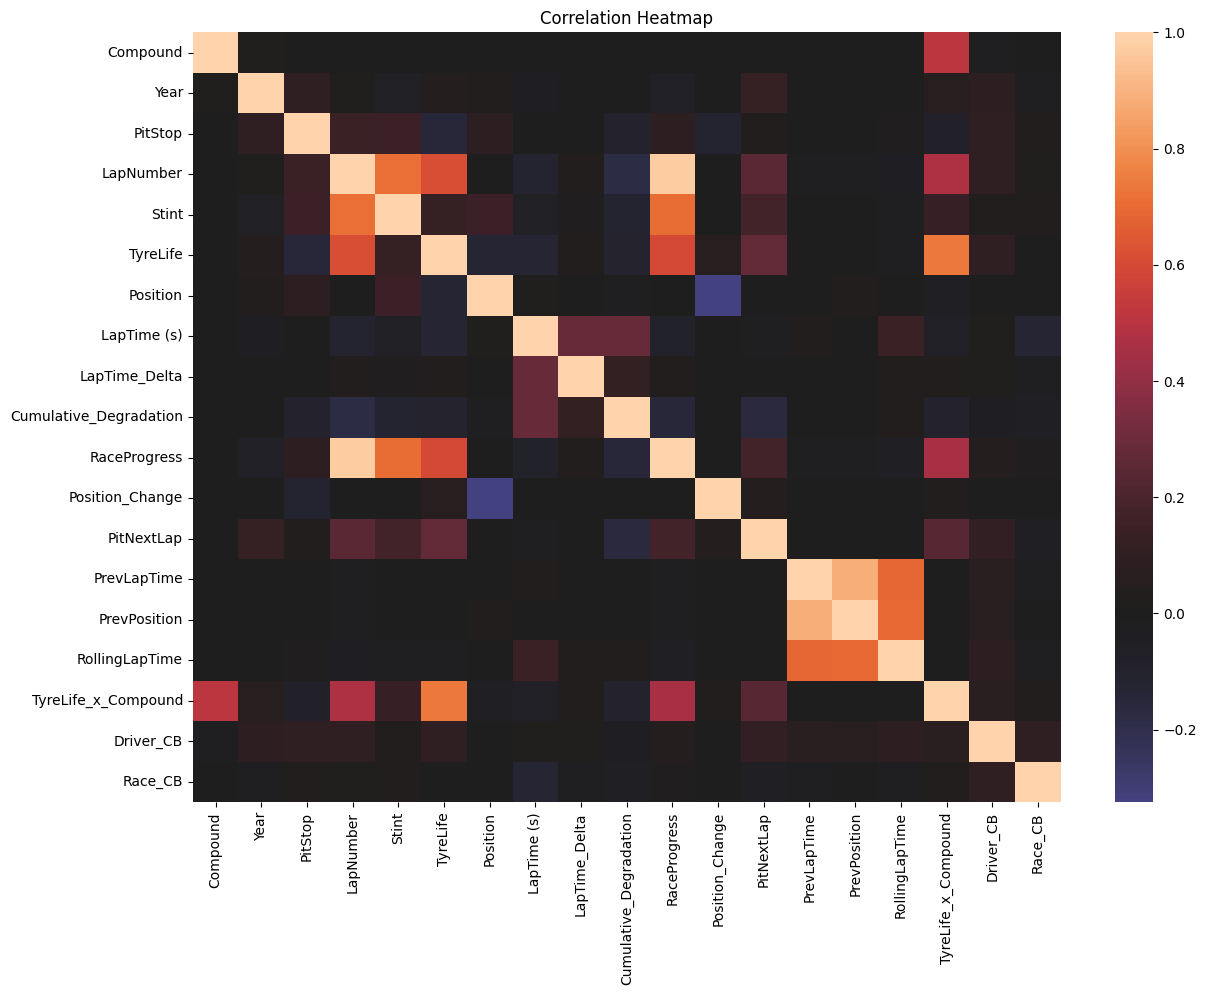

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical columns only
corr_matrix = train_data.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    #cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
cat_cols = train_data.select_dtypes(include='object').columns.tolist()
cat_cols

[]

In [25]:
train_data.columns

Index(['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'PitNextLap', 'PrevLapTime',
       'PrevPosition', 'RollingLapTime', 'TyreLife_x_Compound', 'Driver_CB',
       'Race_CB'],
      dtype='object')

In [26]:
X=train_data.drop('PitNextLap',axis=1)
y=train_data.PitNextLap

In [27]:
scaler = StandardScaler()

X = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

In [30]:
class F1Dataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [31]:
class PitStopNN(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden1,
        hidden2,
        dropout
    ):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, hidden1),

            nn.BatchNorm1d(hidden1),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),

            nn.BatchNorm1d(hidden2),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(hidden2, 64),

            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.model(x)

In [32]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using {device} device")

Using cuda device


In [33]:
def objective(trial):

    # -----------------------------------
    # HYPERPARAMETERS
    # -----------------------------------

    hidden1 = trial.suggest_int("hidden1", 128, 512)

    hidden2 = trial.suggest_int("hidden2", 64, 256)

    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    batch_size = trial.suggest_categorical(
        "batch_size",
        [128, 256, 512]
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-2,
        log=True
    )

    # -----------------------------------
    # GROUP KFOLD
    # -----------------------------------

    gkf = GroupKFold(n_splits=3)

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        print(f"\n========== Fold {fold+1} ==========")

        X_train = X[train_idx]
        X_val = X[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # -----------------------------------
        # DATASETS
        # -----------------------------------

        train_dataset = F1Dataset(X_train, y_train)
        val_dataset = F1Dataset(X_val, y_val)

        # -----------------------------------
        # DATALOADERS
        # -----------------------------------

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True
        )

        # -----------------------------------
        # MODEL
        # -----------------------------------

        model = PitStopNN(
            input_dim=X.shape[1],
            hidden1=hidden1,
            hidden2=hidden2,
            dropout=dropout
        ).to(device)

        # -----------------------------------
        # LOSS FUNCTION
        # -----------------------------------

        criterion = nn.BCEWithLogitsLoss()

        # -----------------------------------
        # OPTIMIZER
        # -----------------------------------

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        # -----------------------------------
        # SCHEDULER
        # -----------------------------------

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            patience=2,
            factor=0.5
        )

        # -----------------------------------
        # EARLY STOPPING
        # -----------------------------------

        best_f1 = 0

        patience = 5

        counter = 0

        EPOCHS = 10

        # -----------------------------------
        # TRAINING LOOP
        # -----------------------------------

        for epoch in range(EPOCHS):

            model.train()

            train_losses = []

            for X_batch, y_batch in train_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                outputs = model(X_batch).squeeze()

                loss = criterion(outputs, y_batch)

                loss.backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

                train_losses.append(loss.item())

            # ====================================
            # VALIDATION
            # ====================================

            model.eval()

            preds = []
            targets = []

            with torch.no_grad():

                for X_batch, y_batch in val_loader:

                    X_batch = X_batch.to(device)

                    outputs = model(X_batch).squeeze()

                    probs = torch.sigmoid(outputs)

                    predictions = (
                        probs > 0.5
                    ).int().cpu().numpy()

                    preds.extend(predictions)

                    targets.extend(y_batch.numpy())

            val_f1 = f1_score(targets, preds)

            scheduler.step(val_f1)

            print(
                f"Epoch {epoch+1} | "
                f"Loss: {np.mean(train_losses):.4f} | "
                f"F1: {val_f1:.4f}"
            )

            # ====================================
            # EARLY STOPPING
            # ====================================

            if val_f1 > best_f1:

                best_f1 = val_f1

                counter = 0

            else:

                counter += 1

                if counter >= patience:

                    print("Early Stopping Triggered")

                    break

        fold_scores.append(best_f1)

    return np.mean(fold_scores)

In [34]:
import optuna
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=5
)

[I 2026-05-21 09:24:52,548] A new study created in memory with name: no-name-f0897ae1-a896-4b14-9a58-e8f3ec8f6b5f



========== Fold 1 ==========
Epoch 1 | Loss: 0.3312 | F1: 0.6433
Epoch 2 | Loss: 0.2986 | F1: 0.6749
Epoch 3 | Loss: 0.2905 | F1: 0.6878
Epoch 4 | Loss: 0.2852 | F1: 0.6778
Epoch 5 | Loss: 0.2816 | F1: 0.6865
Epoch 6 | Loss: 0.2798 | F1: 0.6637
Epoch 7 | Loss: 0.2756 | F1: 0.6803
Epoch 8 | Loss: 0.2743 | F1: 0.6684
Early Stopping Triggered

========== Fold 2 ==========
Epoch 1 | Loss: 0.3298 | F1: 0.6006
Epoch 2 | Loss: 0.2989 | F1: 0.6294
Epoch 3 | Loss: 0.2904 | F1: 0.5975
Epoch 4 | Loss: 0.2844 | F1: 0.6178
Epoch 5 | Loss: 0.2813 | F1: 0.6466
Epoch 6 | Loss: 0.2779 | F1: 0.6127
Epoch 7 | Loss: 0.2755 | F1: 0.6545
Epoch 8 | Loss: 0.2739 | F1: 0.6603
Epoch 9 | Loss: 0.2716 | F1: 0.6445
Epoch 10 | Loss: 0.2701 | F1: 0.6441

========== Fold 3 ==========
Epoch 1 | Loss: 0.3266 | F1: 0.6898
Epoch 2 | Loss: 0.2925 | F1: 0.7078
Epoch 3 | Loss: 0.2845 | F1: 0.7077
Epoch 4 | Loss: 0.2799 | F1: 0.7082
Epoch 5 | Loss: 0.2767 | F1: 0.7044
Epoch 6 | Loss: 0.2738 | F1: 0.7022
Epoch 7 | Loss: 0.27

[I 2026-05-21 09:30:01,239] Trial 0 finished with value: 0.6854304528235174 and parameters: {'hidden1': 272, 'hidden2': 247, 'dropout': 0.39279757672456206, 'lr': 0.0006251373574521745, 'batch_size': 128, 'weight_decay': 0.0029154431891537554}. Best is trial 0 with value: 0.6854304528235174.


Epoch 9 | Loss: 0.2660 | F1: 0.6998
Early Stopping Triggered

========== Fold 1 ==========
Epoch 1 | Loss: 0.2993 | F1: 0.6229
Epoch 2 | Loss: 0.2798 | F1: 0.6301
Epoch 3 | Loss: 0.2732 | F1: 0.6836
Epoch 4 | Loss: 0.2687 | F1: 0.6462
Epoch 5 | Loss: 0.2658 | F1: 0.6511
Epoch 6 | Loss: 0.2634 | F1: 0.6883
Epoch 7 | Loss: 0.2610 | F1: 0.6645
Epoch 8 | Loss: 0.2590 | F1: 0.6659
Epoch 9 | Loss: 0.2578 | F1: 0.6698
Epoch 10 | Loss: 0.2516 | F1: 0.6703

========== Fold 2 ==========
Epoch 1 | Loss: 0.2994 | F1: 0.6326
Epoch 2 | Loss: 0.2791 | F1: 0.6544
Epoch 3 | Loss: 0.2717 | F1: 0.6347
Epoch 4 | Loss: 0.2679 | F1: 0.6630
Epoch 5 | Loss: 0.2648 | F1: 0.6213
Epoch 6 | Loss: 0.2623 | F1: 0.6497
Epoch 7 | Loss: 0.2604 | F1: 0.6265
Epoch 8 | Loss: 0.2537 | F1: 0.6454
Epoch 9 | Loss: 0.2515 | F1: 0.6257
Early Stopping Triggered

========== Fold 3 ==========
Epoch 1 | Loss: 0.2936 | F1: 0.6970
Epoch 2 | Loss: 0.2745 | F1: 0.6771
Epoch 3 | Loss: 0.2676 | F1: 0.6792
Epoch 4 | Loss: 0.2623 | F1: 0.

[I 2026-05-21 09:35:28,469] Trial 1 finished with value: 0.6845919137803503 and parameters: {'hidden1': 359, 'hidden2': 200, 'dropout': 0.10823379771832098, 'lr': 0.008123245085588688, 'batch_size': 128, 'weight_decay': 5.415244119402541e-06}. Best is trial 0 with value: 0.6854304528235174.


...

Epoch 10 | Loss: 0.2840 | F1: 0.6962

========== Fold 1 ==========
Epoch 1 | Loss: 0.3440 | F1: 0.6118
Epoch 2 | Loss: 0.2992 | F1: 0.6458
Epoch 3 | Loss: 0.2898 | F1: 0.6531
Epoch 4 | Loss: 0.2837 | F1: 0.6654
Epoch 5 | Loss: 0.2794 | F1: 0.6669
Epoch 6 | Loss: 0.2759 | F1: 0.6716
Epoch 7 | Loss: 0.2727 | F1: 0.6698
Epoch 8 | Loss: 0.2699 | F1: 0.6687
Epoch 9 | Loss: 0.2681 | F1: 0.6680
Epoch 10 | Loss: 0.2649 | F1: 0.6755

========== Fold 2 ==========
Epoch 1 | Loss: 0.3446 | F1: 0.5943
Epoch 2 | Loss: 0.3019 | F1: 0.6025
Epoch 3 | Loss: 0.2914 | F1: 0.6166
Epoch 4 | Loss: 0.2846 | F1: 0.6155
Epoch 5 | Loss: 0.2794 | F1: 0.6359
Epoch 6 | Loss: 0.2753 | F1: 0.6311
Epoch 7 | Loss: 0.2718 | F1: 0.6401
Epoch 8 | Loss: 0.2688 | F1: 0.6436
Epoch 9 | Loss: 0.2665 | F1: 0.6414
Epoch 10 | Loss: 0.2649 | F1: 0.6446

========== Fold 3 ==========
Epoch 1 | Loss: 0.3373 | F1: 0.6874
Epoch 2 | Loss: 0.2945 | F1: 0.6833
Epoch 3 | Loss: 0.2840 | F1: 0.7024
Epoch 4 | Loss: 0.2780 | F1: 0.7012
Epoch 5

[I 2026-05-21 09:43:41,946] Trial 3 finished with value: 0.6741525651322119 and parameters: {'hidden1': 303, 'hidden2': 215, 'dropout': 0.1798695128633439, 'lr': 0.0003489018845491386, 'batch_size': 512, 'weight_decay': 4.809461967501575e-06}. Best is trial 0 with value: 0.6854304528235174.


Epoch 8 | Loss: 0.2643 | F1: 0.6972
Early Stopping Triggered

========== Fold 1 ==========
Epoch 1 | Loss: 0.3377 | F1: 0.6614
Epoch 2 | Loss: 0.3009 | F1: 0.6602
Epoch 3 | Loss: 0.2940 | F1: 0.6788
Epoch 4 | Loss: 0.2902 | F1: 0.6878
Epoch 5 | Loss: 0.2874 | F1: 0.6842
Epoch 6 | Loss: 0.2850 | F1: 0.6758
Epoch 7 | Loss: 0.2841 | F1: 0.6861
Epoch 8 | Loss: 0.2805 | F1: 0.6907
Epoch 9 | Loss: 0.2790 | F1: 0.6851
Epoch 10 | Loss: 0.2776 | F1: 0.6798

========== Fold 2 ==========
Epoch 1 | Loss: 0.3364 | F1: 0.6123
Epoch 2 | Loss: 0.3029 | F1: 0.6457
Epoch 3 | Loss: 0.2951 | F1: 0.6349
Epoch 4 | Loss: 0.2904 | F1: 0.6496
Epoch 5 | Loss: 0.2876 | F1: 0.6584
Epoch 6 | Loss: 0.2851 | F1: 0.6566
Epoch 7 | Loss: 0.2832 | F1: 0.6464
Epoch 8 | Loss: 0.2821 | F1: 0.6520
Epoch 9 | Loss: 0.2772 | F1: 0.6489
Epoch 10 | Loss: 0.2760 | F1: 0.6532
Early Stopping Triggered

========== Fold 3 ==========
Epoch 1 | Loss: 0.3324 | F1: 0.6884
Epoch 2 | Loss: 0.2962 | F1: 0.7055
Epoch 3 | Loss: 0.2886 | F1: 0

[I 2026-05-21 09:46:22,426] Trial 4 finished with value: 0.6875707103447074 and parameters: {'hidden1': 153, 'hidden2': 247, 'dropout': 0.4862528132298237, 'lr': 0.002661901888489057, 'batch_size': 512, 'weight_decay': 5.762487216478604e-05}. Best is trial 4 with value: 0.6875707103447074.


Epoch 10 | Loss: 0.2709 | F1: 0.7105


In [35]:
print("Best F1 Score:")
print(study.best_value)

print("\nBest Parameters:")
print(study.best_params)

Best F1 Score:
0.6875707103447074

Best Parameters:
{'hidden1': 153, 'hidden2': 247, 'dropout': 0.4862528132298237, 'lr': 0.002661901888489057, 'batch_size': 512, 'weight_decay': 5.762487216478604e-05}


In [36]:
best_params = study.best_params

model = PitStopNN(
    input_dim=X.shape[1],
    hidden1=best_params["hidden1"],
    hidden2=best_params["hidden2"],
    dropout=best_params["dropout"]
).to(device)

print(model)

PitStopNN(
  (model): Sequential(
    (0): Linear(in_features=18, out_features=153, bias=True)
    (1): BatchNorm1d(153, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4862528132298237, inplace=False)
    (4): Linear(in_features=153, out_features=247, bias=True)
    (5): BatchNorm1d(247, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4862528132298237, inplace=False)
    (8): Linear(in_features=247, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [37]:
X_test_tensor = torch.tensor(
    test_df.values,
    dtype=torch.float32
).to(device)

model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor).squeeze()

    probs = torch.sigmoid(outputs)

    predictions = (probs > 0.5).int().cpu().numpy()

In [38]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv"
)

print(sample_submission.head())

       id  PitNextLap
0  439140           0
1  439141           0
2  439142           0
3  439143           0
4  439144           0


In [39]:
submission = pd.DataFrame({

    "id": sample_submission["id"],

    "PitNextLap": predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())

       id  PitNextLap
0  439140           1
1  439141           1
2  439142           1
3  439143           1
4  439144           1
